# Physics Informed Neural Network (PINN) for Advection-diffusion Model in Porous Materials with Varying transport properties

**Date:** March 13th, 2026

The advection-diffusion-reaction equation is given by:

$$
\beta \frac{\partial u}{\partial t} + \nabla \cdot (V(x) u - D(x) \nabla u) = \sigma (u),
$$ 

where $\beta$ is the porosity term, $V$ is the Darcy velocity, $D$ is the dispersion/diffusion term and $\sigma (u)$ can be a non-linear function of the concentration.

Here we add a small NN to recover spatially varying transport properties ($V(x)$, $D(x)$).

In [444]:
# import libraries
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from keras import layers
from time import time
import matplotlib.pyplot as plt
import os

In [445]:
PHASE1_EPOCHS = 2000   # freeze u/D, fit c to data
PHASE2_EPOCHS = 5000   # unfreeze u/D, joint training
TOTAL_EPOCHS  = PHASE1_EPOCHS + PHASE2_EPOCHS

# Phase 1 weights
weights_phase1 = [0.0,   # pde   ← off
                  50.0,  # data  ← dominant
                  5.0,   # ic
                  5.0,   # bc
                  0.0]   # reg   ← off

# Phase 2 weights: full physics
weights_phase2 = [1.0,   # pde
                  50.0,  # data
                  1.0,   # ic
                  1.0,   # bc
                  1e-4]  # reg

In [446]:
# Input parameters
tol = 1e-8 # Tolerance for convergence

# Data
test_case = "advection_diffusion_varying_profiles" # testcase
data_file = "data/" + test_case
coarsen_data = 1 # Coarsen data by this factor
data_perturbation = 0.e-2 # Perturb data 

# Training parameters
train_parameters = True
nparm = 0 # Number of parameters to train (now using networks instead)
param_perturbation = 1.2 # Perturb parameters by this factor
learning_rate_param = 1e-3 # Learning rate for the parameter networks (reduced for stability)
train_parameters_epoch = 1000 # Number of epochs to train the parameters

# Parameter network architecture
param_network_layers = 3  # Number of hidden layers for u(x) and D(x) networks
param_network_neurons = 50  # Neurons per layer
param_activation = 'tanh'  # Activation for parameter networks

# Loss function weigths
pde_weight = 1.      # penalty for the PDE
data_weight = 50.     # penalty for the data fitting (will be multiplied by param_data_factor)
ic_weight = 1.    # penalty for the initial condition
bc_weight = 1.     # penalty for the boundary condition
reg_weight = 1e-4   # penalty for parameter smoothness

# Parameters for the neural network (NN)
epochs = 5000 # Number of epochs to train the NN
epoch_print = 10 # number fo epochs to print the training progress

learning_rate_val = 1e-2 # Learning rate for the NN
learning_rate_decay_factor = 0.98 # Learning rate decay factor
learning_rate_step = 100 # Learning rate decay step

num_hidden_layers = 8 # Number of hidden layers in the NN
num_neurons = 20 # Number of neurons in each hidden layer
num_neurons_layer = num_neurons # The same number of neurons in each hidden layer

activation = "tanh" # Activation function for the hidden layers
reaction_model = "" # Reaction model

In [447]:
# Create the learning rate scheduler
epochs_array = np.arange(learning_rate_step, epochs + learning_rate_step, learning_rate_step)
decay_steps = np.array([learning_rate_val*learning_rate_decay_factor**i 
                        for i in range(int(epochs/learning_rate_step)+1)])

learning_rate = keras.optimizers.schedules.PiecewiseConstantDecay(
                    boundaries=epochs_array, values=decay_steps)

In [448]:
# Open de data file

# Check if the data directory exists
if os.path.exists(data_file):
    print(f"Data directory '{data_file}' exists.")
else:
    print(f"Data directory '{data_file}' not found. Please check the path and filename.")

# Load the data 
try:
    p = pd.read_csv(data_file + "/p.csv", header=None).values # Parameters array
    x_grid = pd.read_csv(data_file + "/x.csv", header=None) # Spatial grid
    t_grid = pd.read_csv(data_file + "/t.csv", header=None) # Temporal grid
    c_data = pd.read_csv(data_file + "/c.csv", header=None) # Solution array

except FileNotFoundError:
    print(f"One or more data files for test case '{test_case}' not found. Please check the paths and filenames.")

# If there is no u and D profile make it constants:
if not os.path.exists(data_file + "/u.csv") or not os.path.exists(data_file + "/D.csv"):
    print("No u and D profiles found. Using constant values.")
    u_actual = np.full_like(x_grid.values.flatten(), p[1]) # Constant advection velocity
    D_actual = np.full_like(x_grid.values.flatten(), p[2]) # Constant diffusion coefficient
else:
    u_actual = pd.read_csv(data_file + "/u.csv", header=None).values.flatten() # Advection velocity profile
    D_actual = pd.read_csv(data_file + "/D.csv", header=None).values.flatten() # Diffusion coefficient profile

Data directory 'data/advection_diffusion_varying_profiles' exists.


In [ ]:
# Grid sizes
nx = x_grid.values.shape[0]
nt = t_grid.values.shape[0]

# Perturb the data 
c_data = c_data * (1 + data_perturbation * np.random.randn(c_data.size).reshape(c_data.shape))

# 2D data array
c_data_2d = np.reshape(c_data.values, (nt, nx))

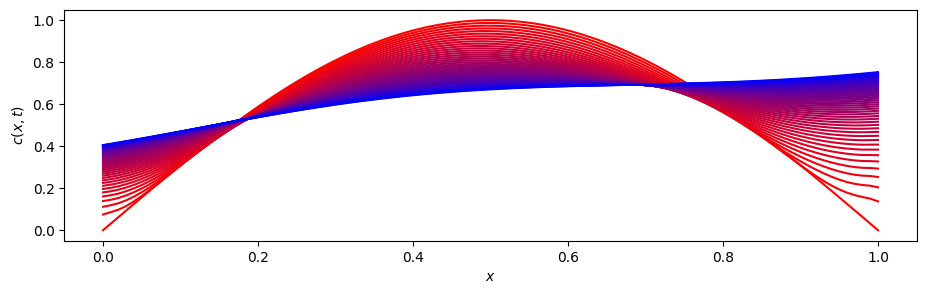

In [450]:
# Figure environment
# Plotting
R = np.linspace(1, 0, nt)
G = 0
B = np.linspace(0, 1, nt)

plt.figure(figsize=(11,3))

for j in range(0, nt, nt//50):
    plt.plot(x_grid, c_data_2d[j, :], color = [R[j], G, B[j]])

plt.xlabel(r"$x$")
plt.ylabel(r"$c(x,t)$")
plt.show()

In [451]:
# Coarsen data if needed
if coarsen_data > 1:

    # New rows and columns for coarsened data
    rows = np.r_[0:nt:coarsen_data, nt-1]
    cols = np.r_[0:nx:coarsen_data, nx-1]

    # Coarsen the grid
    x_grid = x_grid.iloc[cols]
    t_grid = t_grid.iloc[rows]

    # Coarsen the data
    c_data_2d = c_data_2d[np.ix_(rows, cols)]
    c_data = c_data_2d.ravel()

In [452]:
# Mesh and time discretization
nt = t_grid.shape[0]
nx = x_grid.shape[0]
X_grid, T_grid = np.meshgrid(x_grid, t_grid)

# Conver the data to numpy arrays
p = np.array(p).squeeze().astype(np.float32)
x_data = np.array(X_grid, dtype=np.float32).flatten()
t_data = np.array(T_grid, dtype=np.float32).flatten()
c_data = np.array(c_data, dtype=np.float32)

# Data to tensors for TensorFlow
x_tf = tf.expand_dims(tf.convert_to_tensor(x_data), -1)
t_tf = tf.expand_dims(tf.convert_to_tensor(t_data), -1)
c_tf = tf.convert_to_tensor(c_data)

# variables definition for tensorflow
tt = tf.Variable(t_tf, dtype=tf.float32)
xx = tf.Variable(x_tf, dtype=tf.float32)

In [453]:
# perturb the parameters
randp = (p * param_perturbation ** (np.random.randn(p.size) * 2 - 1)).astype(np.float32)

# Aditional parameters for the model (now only beta0 is fixed)
beta0 = randp[0] # Porosity fixed (constant)
sigma = keras.Variable([randp[3]], dtype = tf.float32, name = "sigma", 
                       trainable = (train_parameters and nparm > 2)) # Reaction coefficient

In [454]:
# Build parameter networks for u(x) and D(x)
def build_parameter_network(name, num_hidden_layers, num_neurons, activation='tanh'):
    """
    Build a neural network that maps x to a parameter value (u(x) or D(x))
    """
    x_input = keras.Input(shape=(1,), name=f'{name}_input')
    
    # Hidden layers
    h = x_input
    for i in range(num_hidden_layers):
        h = layers.Dense(
            num_neurons,
            activation=activation,
            kernel_initializer='glorot_normal',
            name=f'{name}_hidden_{i}'
        )(h)
    
    # Output layer
    if name == 'D_network':
        # Use softplus to ensure positivity for diffusion coefficient
        output = layers.Dense(1, activation='softplus', name=f'{name}_output')(h)
    else:
        output = layers.Dense(1, activation='linear', name=f'{name}_output')(h)
    
    model = keras.Model(inputs=x_input, outputs=output, name=name)
    return model

In [455]:
# Create parameter networks
u_network = build_parameter_network('u_network', param_network_layers, param_network_neurons, param_activation)
D_network = build_parameter_network('D_network', param_network_layers, param_network_neurons, param_activation)

print(f"\nParameter networks created:")
print(f"u_network: {u_network.count_params()} parameters")
print(f"D_network: {D_network.count_params()} parameters")



Parameter networks created:
u_network: 5251 parameters
D_network: 5251 parameters


In [456]:
# Store parameters list (now including the networks)
params = [sigma]  # sigma is the only constant parameter being trained
params0 = [p[3]]  # Initial sigma value

# Params names
params_names = ["sigma"]

print(f"Initial parameters: ")
for i in range(len(params0)):
    print(f"{params_names[i]}: {params0[i]}")

if param_perturbation > 0:
    print(f"\nInitial parameters (perturbed):")
    for i in range(len(params)):
        print(f"{params_names[i]}: {randp[3+i]}")

Initial parameters: 
sigma: 0.0

Initial parameters (perturbed):
sigma: 0.0


In [457]:
# non-linear reaction term
@tf.function(reduce_retracing=True)
def reaction(c, sigma=sigma, sigma2=1.0e-1, forward_rate=3.0, backward_rate=3.0):
    """ 
    Function reaction term for the PDE. It can be modified to include different reaction models.
        Inputs:
            c(array, float): concentration
            sigma(float): reaction coefficient
            sigma2(float): second reaction coefficient
            forward_rate(float): forward reaction rate
            backward_rate(float): backward reaction rate
        Output:
            reaction term
    """
    if (reaction_model == 'michaelis-menten'):
        return sigma * c**forward_rate / (sigma2 + c**backward_rate) # michaelis-menten kinetics
    elif (reaction_model == 'linear'):
        return sigma * c # linear reaction
    elif (reaction_model == 'quadratic'):
        return sigma * c**2
    elif (reaction_model == 'polynomial'): # Polynomial reaction
        return sigma * c**forward_rate * (1 - c)**backward_rate
    else:
        print('Reaction model not implemented') # Homogeneous reaction (no reaction)
        return tf.zeros_like(c)

In [458]:
# NN construction
def pinn_model(num_hidden_layers=num_hidden_layers, num_neurons_per_layer=num_neurons_layer):
    """
    Function to construct the physics-informed neural network (PINN) model for the advection-diffusion-reaction equation.
        Inputs:
            num_hidden_layers(int): number of hidden layers in the NN
            num_neurons_per_layer(int): number of neurons in each hidden layer
        Output:
            PINN model
    """

    # Create the input layers for the spatial and temporal coordinates
    x_input = keras.Input(shape=(1,))
    t_input = keras.Input(shape=(1,))

    output_c = layers.concatenate([t_input, x_input]) # input layer
    
    # Build the hidden layers
    for i in range(num_hidden_layers):
        output_c = layers.Dense(num_neurons_per_layer,
                                         activation=activation,  
                                         kernel_initializer='glorot_normal',
                                         )(output_c)
    
    # output layer (a single neuron for the concentration)
    output_c = layers.Dense(1)(output_c)

    return keras.Model(inputs=[t_input, x_input], outputs=output_c) # Return the model

In [459]:
@tf.function(reduce_retracing=True)
def custom_loss(inputs, model, u_network, D_network, beta0, sigma, u_true_mean=0.5, D_true_mean=0.1):

    xx, tt, cc = inputs

    with tf.GradientTape(persistent=True) as tape:
        tape.watch(tt)
        tape.watch(xx)

        output_model = model([tt, xx])
        c_model = tf.expand_dims(output_model[:, 0], -1)

        c_x = tape.gradient(c_model, xx)
        c_t = tape.gradient(c_model, tt)

        u_val = u_network(xx)
        D_val = D_network(xx)

        uc    = u_val * c_model
        uc_x  = tape.gradient(uc, xx)
        D_cx  = D_val * c_x
        D_cx_x = tape.gradient(D_cx, xx)

        # Smoothness: gradient of u and D at training points (inside tape, no noise)
        u_x = tape.gradient(u_val, xx)
        D_x = tape.gradient(D_val, xx)

    del tape

    # PDE
    pde_residual = beta0 * c_t + uc_x - D_cx_x - reaction(c_model, sigma)
    pde_loss = tf.reduce_mean(pde_residual ** 2)

    # Data
    data_fitting_loss = tf.reduce_mean((c_model - cc) ** 2)

    # IC
    ic_fitting_loss = tf.reduce_mean((c_model[0:nt] - cc[0:nt]) ** 2)

    # No-flux BC
    flux_left  = u_val[0::nx]    * c_model[0::nx]    - D_val[0::nx]    * c_x[0::nx]
    flux_right = u_val[nx-1::nx] * c_model[nx-1::nx] - D_val[nx-1::nx] * c_x[nx-1::nx]
    bc_fitting_loss = tf.reduce_mean(flux_left**2 + flux_right**2)

    # Smoothness: single weight, no double scaling
    reg_loss = tf.reduce_mean(u_x**2) + tf.reduce_mean(D_x**2)

    # Add to custom_loss return, after the reg_loss line:
    x_anchor = tf.linspace(0.0, 1.0, 50)[:, None]
    u_anchor = u_network(tf.cast(x_anchor, tf.float32))
    D_anchor = D_network(tf.cast(x_anchor, tf.float32))

    anchor_loss = ((tf.reduce_mean(u_anchor) - u_true_mean) ** 2 +
                (tf.reduce_mean(D_anchor) - D_true_mean) ** 2)

    return [pde_loss, data_fitting_loss, ic_fitting_loss, 
            bc_fitting_loss, reg_loss, anchor_loss]

In [460]:
# @tf.function(reduce_retracing=True)
# def custom_loss(inputs, model, u_network, D_network, beta0, sigma):

#     # Define the model inputs
#     xx, tt, cc = inputs

#     # Compute derivatives - Use a single tape for all derivatives
#     with tf.GradientTape(persistent=True) as tape:
#         # Make the tape watch the input variables
#         tape.watch(tt)
#         tape.watch(xx)

#         # Compute the model output
#         output_model = model([tt, xx])

#         # Extract the concentration from the model output
#         c_model = output_model[:, 0]
#         c_model = tf.expand_dims(c_model, -1) # Correct dimensions

#         # First derivatives
#         c_x = tape.gradient(c_model, xx)
#         c_t = tape.gradient(c_model, tt)
        
#         # Get spatially varying parameters (need to compute gradients of u and D)
#         u_val = u_network(xx)
#         D_val = D_network(xx)
        
#         # Compute advection term: u * c
#         uc = u_val * c_model
        
#         # Gradient of advection term
#         uc_x = tape.gradient(uc, xx)
        
#         # Compute diffusion term: D * c_x
#         D_cx = D_val * c_x
        
#         # Gradient of diffusion term
#         D_cx_x = tape.gradient(D_cx, xx)
    
#     # Clean up tape
#     del tape

#     # PDE residual (including reaction term)
#     pde_residual = beta0 * c_t + uc_x - D_cx_x - reaction(c_model, sigma)
    
#     # Compute the components of loss function
#     norm_weight = 1.0
#     pde_loss = tf.reduce_mean(tf.multiply(norm_weight, pde_residual ** 2))
    
#     data_fitting_loss = tf.reduce_mean((c_model - cc) ** 2) # data misfit
#     bc_fitting_loss = tf.reduce_mean((c_model[::nx] - cc[::nx]) ** 2 # dirichlet based on data
#                             + (c_x[(nx-1)::nx]) ** 2) # neumann zero
#     ic_fitting_loss = tf.reduce_mean((c_model[0:nt] - cc[0:nt]) ** 2) # initial condition based on data
    
#     # Smoothness regularization for parameter networks
#     # Sample points for regularization
#     x_sample = tf.random.uniform([1000, 1], minval=0.0, maxval=1.0)
#     with tf.GradientTape(persistent=True) as tape_reg:
#         tape_reg.watch(x_sample)
#         u_sample = u_network(x_sample)
#         D_sample = D_network(x_sample)
#         u_x_reg = tape_reg.gradient(u_sample, x_sample)
#         D_x_reg = tape_reg.gradient(D_sample, x_sample)
    
#     reg_loss = param_reg_weight * (tf.reduce_mean(u_x_reg**2) + tf.reduce_mean(D_x_reg**2))
#     del tape_reg
    
#     return [pde_loss, data_fitting_loss, ic_fitting_loss, bc_fitting_loss, reg_loss]

In [461]:
# PINN model definition
model = pinn_model(num_hidden_layers=num_hidden_layers, num_neurons_per_layer=num_neurons_layer)

# Trainable variables for the optimizer
trainable = model.trainable_variables 

# Add parameter networks to trainable variables
if train_parameters:
    print(f"Training spatially varying parameters u(x) and D(x)")
    trainable.extend(u_network.trainable_variables)
    trainable.extend(D_network.trainable_variables)
    # Add sigma if training it
    if nparm > 0:
        trainable.append(sigma)

print(f"\nTotal number of trainable objects: {len(trainable)}")
print(f"  - Concentration network: {len(model.trainable_variables)}")
print(f"  - u_network: {len(u_network.trainable_variables)}")
print(f"  - D_network: {len(D_network.trainable_variables)}")
if nparm > 0:
    print(f"  - sigma: 1")

# Create the optimizer
optimizer_c = keras.optimizers.Adam(learning_rate=learning_rate, amsgrad=True)
optimizer_params = keras.optimizers.Adam(learning_rate=learning_rate_param, amsgrad=True)

Training spatially varying parameters u(x) and D(x)

Total number of trainable objects: 34
  - Concentration network: 18
  - u_network: 8
  - D_network: 8


In [462]:
# Create empty lists to store the loss history (now 10 components)
losses = np.zeros((TOTAL_EPOCHS, 11))  # 5
param_values = np.zeros((TOTAL_EPOCHS, 1))  # Only sigma
param_grads = np.zeros((TOTAL_EPOCHS, 1))  # Only sigma gradients
l2_errors = np.zeros((TOTAL_EPOCHS, 1))

# Create arrays to store parameter profiles for visualization
u_profile_history = []
D_profile_history = []
x_profile = x_grid.values.flatten()

print("\nStarting training with spatially varying parameters...")
print(f"Total epochs: {TOTAL_EPOCHS}")
print(f"Parameter networks: {param_network_layers} layers, {param_network_neurons} neurons")


Starting training with spatially varying parameters...
Total epochs: 7000
Parameter networks: 3 layers, 50 neurons


In [463]:
# # Main loop
# stop = False
# t0 = time() # Start time
# t1 = t0

# for epoch in range(epochs):

#     # Update the learning rate in function of the epoch
#     lr = learning_rate(epoch)

#     if train_parameters:
#         # tanh transition
#         param_data_factor = (np.tanh(10 * (epoch - epochs / 2 - train_parameters_epoch) / epochs) + 1) / 2
        
#         # set the parameter to zero for the first epochs
#         param_data_factor *= (epoch > train_parameters_epoch) # Set to zero for the first epochs

#     else:
#         param_data_factor = 1.0
    
#     # Compute and normalize the weights for the loss function (now 5 components)
#     weights = [pde_weight, data_weight*param_data_factor, ic_weight, bc_weight, reg_weight]
#     # weights = [w/sum(weights) for w in weights]

#     # Compute the gradients
#     with tf.GradientTape(persistent=True) as tape:

#         # Call the tf decorated loss function (now with 5 components)
#         loss0 = custom_loss([xx, tt, c_tf], model, u_network, D_network, beta0, sigma)
#         loss = [l * w for l, w in zip(loss0, weights)] # weight the losses

#         # Append the total loss
#         loss.append(sum(loss)) # weighted total loss

#     gradients = tape.gradient(loss[-1], trainable)

#     del tape
    
#     if (train_parameters):
#         if nparm > 0:
#             param_grads[epoch,:] = np.array(gradients[-nparm:]).squeeze()/weights[0] # Store parameter gradients
            
#             # Gradients scaling (parameters)
#             for i in range(-nparm,0):
#                 gradients[i] *= learning_rate_param * param_data_factor
        
#         # Note: u_network and D_network gradients are scaled by the main learning rate
#         # Their learning rates are controlled by the optimizer
    
#     # Minimize the gradients (update the model parameters)
#     optimizer.apply_gradients(zip(gradients, trainable))    
    
#     # Store losses (5 unweighted + 5 weighted + total = 11? Actually we have 10)
#     losses[epoch,:5] = np.array(loss0)
#     losses[epoch,5:9] = np.array(loss[:4])  # weighted losses
#     losses[epoch,9] = loss[-1]  # total loss
    
#     # Store sigma value
#     if nparm > 0:
#         param_values[epoch,:] = sigma.numpy().squeeze()
    
#     # Store parameter profiles every 100 epochs
#     if epoch % 100 == 0:
#         x_eval = x_profile.reshape(-1, 1)
#         x_eval_tf = tf.convert_to_tensor(x_eval, dtype=tf.float32)
#         u_profile = u_network(x_eval_tf).numpy().flatten()
#         D_profile = D_network(x_eval_tf).numpy().flatten()
#         u_profile_history.append(u_profile)
#         D_profile_history.append(D_profile)
    
#     # l2 errors
#     sol = model([t_data, x_data]).numpy().reshape(nt, nx)
#     l2_errors[epoch] = np.linalg.norm(sol - c_data_2d)/np.linalg.norm(c_data_2d)
    
#     # Print the results
#     if epoch % epoch_print == 0:
#         print(f"\nEpoch {epoch + 1}/{epochs}")
#         print(f"Total loss: {loss[-1].numpy():.6e}")
#         print(f"  PDE loss: {loss0[0].numpy():.6e}")
#         print(f"  Data loss: {loss0[1].numpy():.6e}")
#         print(f"  IC loss: {loss0[2].numpy():.6e}")
#         print(f"  BC loss: {loss0[3].numpy():.6e}")
#         print(f"  Reg loss: {loss0[4].numpy():.6e}")

#         # cpu time
#         print('CPU time for {} epochs: {:.2f} seconds'.format(epoch_print, time() - t1))
#         t1 = time()

#         # l2 error
#         print("l2 space-time relative error: {:.6f}".format(l2_errors[epoch][0]))
            
#         # parameters
#         if nparm > 0:
#             print(f"param_data_factor = {param_data_factor:.2e}, sigma = {sigma.numpy()[0]:.4e}")
#         else:
#             print(f"param_data_factor = {param_data_factor:.2e}")
        
#         # Show sample parameter values
#         if epoch % 100 == 0 and len(u_profile_history) > 0:
#             print(f"  u(0) = {u_profile[0]:.4f}, u(0.5) = {u_profile[nx//2]:.4f}, u(1) = {u_profile[-1]:.4f}")
#             print(f"  D(0) = {D_profile[0]:.4f}, D(0.5) = {D_profile[nx//2]:.4f}, D(1) = {D_profile[-1]:.4f}")
    
#     # Early stopping (check convergence of total loss)
#     if epoch > 2*train_parameters_epoch:
#         if np.abs(losses[epoch, -1] - losses[max(0, epoch-100), -1]) < tol*losses[0, -1]:  
#             print('Loss is not decreasing anymore. Stopping training.')
#             break
            
# # Print computation time
# print('\nTotal training CPU time: {:.2f} seconds'.format(time() - t0))

In [464]:
# Compute the mean values of u and D for the anchor loss
u_true_mean = float(np.mean(u_actual))
D_true_mean = float(np.mean(D_actual))

In [ ]:
# Phase 1: Fit c to data with u and D frozen
for epoch in range(PHASE1_EPOCHS):

    # Only c-network is trained
    trainable_now = model.trainable_variables

    with tf.GradientTape() as tape:
        loss0 = custom_loss([xx, tt, c_tf], model, u_network, D_network, beta0, sigma, u_true_mean, D_true_mean)
        loss  = [l * w for l, w in zip(loss0, weights_phase1)]
        loss.append(sum(loss))

    gradients = tape.gradient(loss[-1], trainable_now)
    optimizer_c.apply_gradients(zip(gradients, trainable_now))

    # Storage
    losses[epoch, :6] = np.array(loss0)
    losses[epoch, 5:9] = np.array(loss[:4])
    losses[epoch, 9]   = loss[-1]

    sol = model([t_data, x_data]).numpy().reshape(nt, nx)
    l2_errors[epoch] = np.linalg.norm(sol - c_data_2d) / np.linalg.norm(c_data_2d)

    if epoch % epoch_print == 0:
        print(f"[Phase 1] Epoch {epoch+1}/{PHASE1_EPOCHS} | "
              f"Total: {loss[-1].numpy():.4e} | "
              f"Data: {loss0[1].numpy():.4e} | "
              f"L2: {l2_errors[epoch][0]:.4f}")

print(f"\nPhase 1 done. Final L2 error: {l2_errors[PHASE1_EPOCHS-1][0]:.4f}")
print("c-network should now fit data well before u/D are trained.")

# Reset optimizer momentum before Phase 2
optimizer_c      = keras.optimizers.Adam(learning_rate=learning_rate, amsgrad=True)
optimizer_params = keras.optimizers.Adam(learning_rate=learning_rate_param, amsgrad=True)

Reaction model not implemented
[Phase 1] Epoch 1/2000 | Total: 2.4895e+01 | Data: 4.4588e-01 | L2: 0.2397
[Phase 1] Epoch 11/2000 | Total: 2.1994e+00 | Data: 3.1491e-02 | L2: 0.3296
[Phase 1] Epoch 21/2000 | Total: 2.1162e+00 | Data: 2.7731e-02 | L2: 0.2525
[Phase 1] Epoch 31/2000 | Total: 1.7929e+00 | Data: 2.3211e-02 | L2: 0.2353
[Phase 1] Epoch 41/2000 | Total: 1.6770e+00 | Data: 2.1619e-02 | L2: 0.2276
[Phase 1] Epoch 51/2000 | Total: 1.6364e+00 | Data: 2.0706e-02 | L2: 0.2223
[Phase 1] Epoch 61/2000 | Total: 1.6132e+00 | Data: 2.0506e-02 | L2: 0.2209
[Phase 1] Epoch 71/2000 | Total: 1.5843e+00 | Data: 1.9994e-02 | L2: 0.2176
[Phase 1] Epoch 81/2000 | Total: 1.5315e+00 | Data: 1.9023e-02 | L2: 0.2116
[Phase 1] Epoch 91/2000 | Total: 1.4203e+00 | Data: 1.7014e-02 | L2: 0.1996
[Phase 1] Epoch 101/2000 | Total: 1.3380e+00 | Data: 1.5807e-02 | L2: 0.1915
[Phase 1] Epoch 111/2000 | Total: 1.0653e+00 | Data: 1.1137e-02 | L2: 0.1565
[Phase 1] Epoch 121/2000 | Total: 7.7006e-01 | Data: 9.9

In [466]:
all_param_vars = u_network.trainable_variables + D_network.trainable_variables
n_c = len(model.trainable_variables)
n_u = len(u_network.trainable_variables)

for epoch in range(PHASE1_EPOCHS, TOTAL_EPOCHS):
    idx = epoch
    phase2_epoch = epoch - PHASE1_EPOCHS

    # Ramp PDE weight in gradually
    pde_ramp = min(1.0, phase2_epoch / 2000)
    weights_phase2 = [0.01 + 0.99 * pde_ramp,  # pde
                      50.0,                      # data
                      1.0,                       # ic
                      1.0,                       # bc
                      1e-4,                      # reg
                      10.0]                      # anchor

    all_trainable = model.trainable_variables + all_param_vars

    with tf.GradientTape() as tape:
        loss0 = custom_loss([xx, tt, c_tf], model, u_network, D_network,
                            beta0, sigma, u_true_mean, D_true_mean)
        total_loss = sum(l * w for l, w in zip(loss0, weights_phase2))

    all_grads = tape.gradient(total_loss, all_trainable)

    grads_c = all_grads[:n_c]
    grads_u = [tf.clip_by_norm(g, 1.0) if g is not None else g 
               for g in all_grads[n_c:n_c+n_u]]
    grads_D = [tf.clip_by_norm(g, 1.0) if g is not None else g 
               for g in all_grads[n_c+n_u:]]

    optimizer_c.apply_gradients(zip(grads_c, model.trainable_variables))
    optimizer_params.apply_gradients(zip(grads_u + grads_D, all_param_vars))

    # Storage
    losses[idx, :6]  = np.array(loss0)
    losses[idx, 5:9] = np.array(loss[:4])
    losses[idx, 9]   = loss[-1]

    sol = model([t_data, x_data]).numpy().reshape(nt, nx)
    l2_errors[idx] = np.linalg.norm(sol - c_data_2d) / np.linalg.norm(c_data_2d)

    if epoch % epoch_print == 0:
        # Parameter profiles
        x_eval = x_profile.reshape(-1, 1).astype(np.float32)
        u_pred = u_network(x_eval).numpy().flatten()
        D_pred = D_network(x_eval).numpy().flatten()
        l2_u = np.linalg.norm(u_pred - u_actual.flatten()) / np.linalg.norm(u_actual.flatten())
        l2_D = np.linalg.norm(D_pred - D_actual.flatten()) / np.linalg.norm(D_actual.flatten())

        print(f"[Phase 2] Epoch {epoch+1}/{TOTAL_EPOCHS} | "
              f"Total: {loss[-1].numpy():.4e} | "
              f"Data: {loss0[1].numpy():.4e} | "
              f"L2 c: {l2_errors[idx][0]:.4f} | "
              f"L2 u: {l2_u:.4f} | "
              f"L2 D: {l2_D:.4f}")

last_epoch = TOTAL_EPOCHS

[Phase 2] Epoch 2001/7000 | Total: 1.4032e-02 | Data: 1.1453e-04 | L2 c: 0.5309 | L2 u: 1.0088 | L2 D: 0.2696
[Phase 2] Epoch 2011/7000 | Total: 1.4032e-02 | Data: 1.7758e-02 | L2 c: 0.1902 | L2 u: 0.4579 | L2 D: 0.2743
[Phase 2] Epoch 2021/7000 | Total: 1.4032e-02 | Data: 1.2213e-02 | L2 c: 0.1815 | L2 u: 0.3270 | L2 D: 0.3108
[Phase 2] Epoch 2031/7000 | Total: 1.4032e-02 | Data: 1.0126e-02 | L2 c: 0.1483 | L2 u: 0.2258 | L2 D: 0.2646
[Phase 2] Epoch 2041/7000 | Total: 1.4032e-02 | Data: 7.1742e-03 | L2 c: 0.1233 | L2 u: 0.0782 | L2 D: 0.2718
[Phase 2] Epoch 2051/7000 | Total: 1.4032e-02 | Data: 4.0703e-03 | L2 c: 0.0964 | L2 u: 0.1897 | L2 D: 0.2458
[Phase 2] Epoch 2061/7000 | Total: 1.4032e-02 | Data: 1.6445e-03 | L2 c: 0.0590 | L2 u: 0.3951 | L2 D: 0.2205
[Phase 2] Epoch 2071/7000 | Total: 1.4032e-02 | Data: 5.8272e-04 | L2 c: 0.0396 | L2 u: 0.5548 | L2 D: 0.2030
[Phase 2] Epoch 2081/7000 | Total: 1.4032e-02 | Data: 5.3596e-04 | L2 c: 0.0354 | L2 u: 0.6142 | L2 D: 0.1841
[Phase 2] 

In [467]:
# Create output directory if it doesn't exist
output_dir = "output/" + test_case + "/"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Output directory '{output_dir}' created.")
else:
    print(f"Output directory '{output_dir}' already exists.")

Output directory 'output/advection_diffusion_varying_profiles/' already exists.


In [486]:
# Define the style for plotting
import scienceplots
plt.style.use(['science', 'notebook', 'no-latex']) 

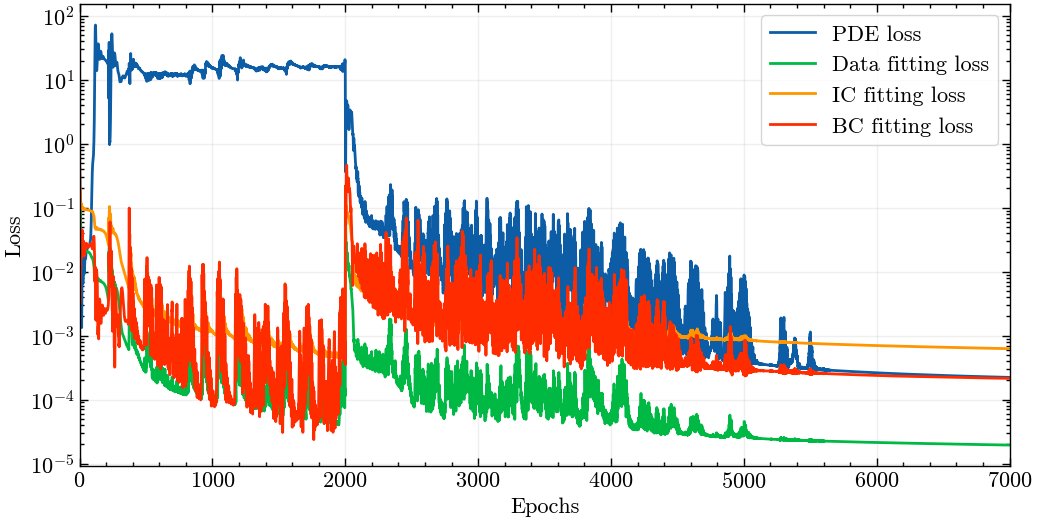

In [489]:
# Plot epochs vs. losses

plt.figure(figsize=(12, 6))
plt.plot(losses[:,0], label='PDE loss')
plt.plot(losses[:,1], label='Data fitting loss')
plt.plot(losses[:,2], label='IC fitting loss')
plt.plot(losses[:,3], label='BC fitting loss')

plt.xlim(0, last_epoch)
#plt.ylim(0, 0.2)

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(alpha=0.2)
plt.legend(frameon = True)

# Log scale for loss
plt.yscale('log')

plt.savefig(output_dir + "/loss_history.pdf", dpi=300)

plt.show()

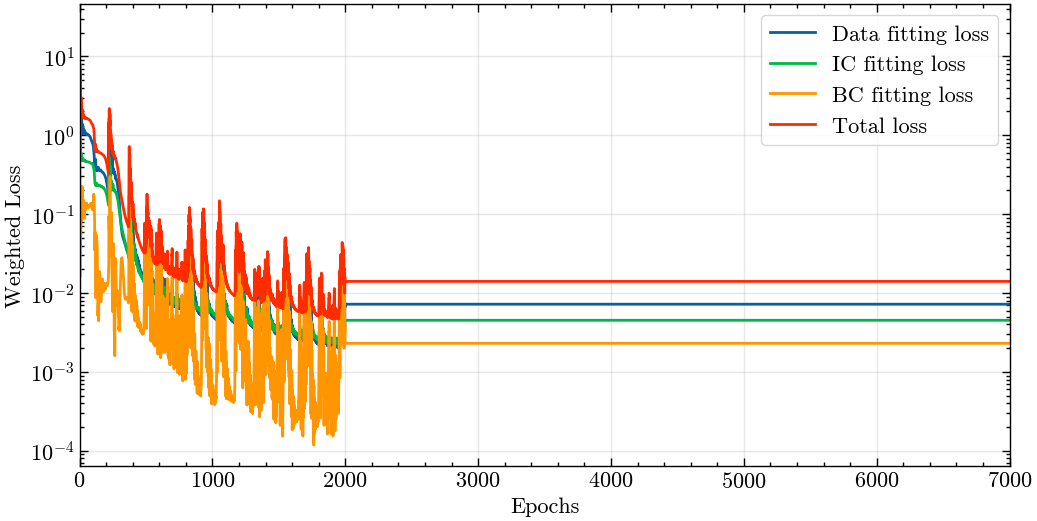

In [499]:
# Plot epochs vs. losses

plt.figure(figsize=(12, 6))
# plt.plot(losses[:, 5], label='PDE loss')
plt.plot(losses[:, 6], label='Data fitting loss')
plt.plot(losses[:, 7], label='IC fitting loss')
plt.plot(losses[:, 8], label='BC fitting loss')
plt.plot(losses[:, 9], label='Total loss')

# Log scale for the loss
plt.yscale('log')

plt.xlim(0, last_epoch)

plt.xlabel('Epochs')
plt.ylabel('Weighted Loss')
plt.grid(alpha=0.3)
plt.legend(frameon = True)

plt.savefig(output_dir + "/loss_history_weighted.pdf", dpi=300)

plt.show()

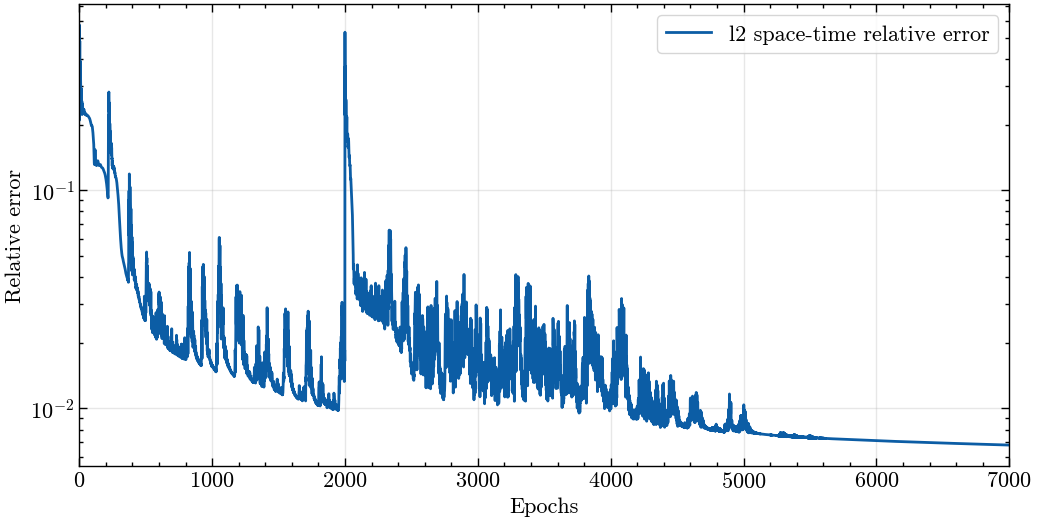

In [501]:
# Plot l2 errors
plt.figure(figsize=(12, 6))

# Solution error
plt.plot(l2_errors, label='l2 space-time relative error')
# Parameter error
for i in range(nparm):
    plt.plot(np.abs(param_values[:,i] - params0[i])/params0[i], label=f'{params_names[i]} relative error')

plt.xlabel('Epochs')
plt.xlim(0, last_epoch)

plt.ylabel('Relative error')
plt.grid(alpha=0.3)
plt.legend(frameon = True)

plt.yscale('log')

plt.savefig(output_dir + "/errors_history.pdf", dpi=300)

plt.show()

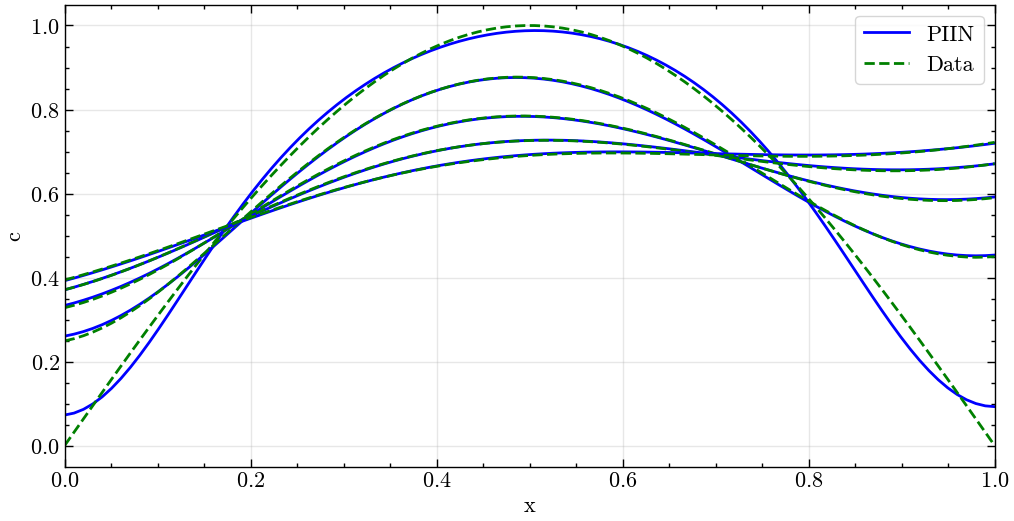

In [504]:
# Plot solutions in space

plt.figure(figsize=(12, 6))

for i in range(0, sol.shape[0], int(sol.shape[0]/5)):
    plt.plot(x_grid, sol[i,:], label='PIIN' if i == 0 else "", color='blue')
    plt.plot(x_grid, c_data_2d[i,:], label='Data' if i == 0 else "", color='green',  linestyle='dashed')
plt.xlabel('x')
plt.ylabel('c')
plt.grid(alpha=0.3)
plt.legend(frameon = True)

plt.xlim(0, 1)

plt.savefig(output_dir + "/solution_profiles.pdf", dpi=300)

plt.show()

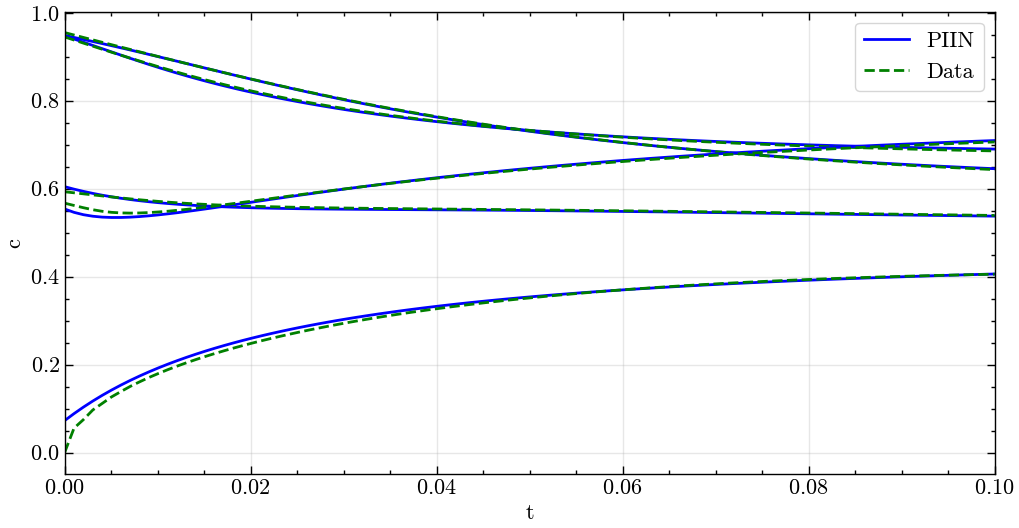

In [505]:
# Plot solutions in space

plt.figure(figsize=(12, 6))

for i in range(0, sol.shape[0], int(sol.shape[0]/5)):
    plt.plot(t_grid, sol[:,i], label='PIIN' if i == 0 else "", color='blue')
    plt.plot(t_grid, c_data_2d[:,i], label='Data' if i == 0 else "", color='green' \
    '',  linestyle='dashed')
plt.xlabel('t')
plt.ylabel('c')
plt.grid(alpha=0.3)
plt.legend(frameon = True)

plt.xlim(0, 0.1)

plt.savefig(output_dir + "/solution_profiles_time.pdf", dpi=300)

plt.show()

In [284]:
# Read actual parameter profiles
D_actual = pd.read_csv(data_file + "/D.csv", header=None).values
u_actual = pd.read_csv(data_file + "/u.csv", header=None).values

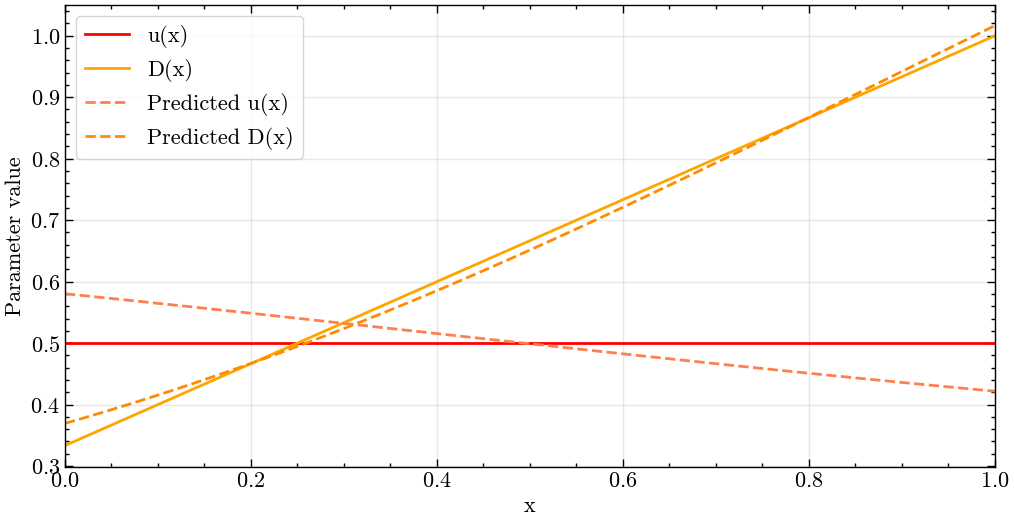

In [509]:
# Plot parameter profiles
plt.figure(figsize=(12, 6))

# Plot actual profiles
plt.plot(x_grid, u_actual.flatten(), label='u(x)', color='red')
plt.plot(x_grid, D_actual.flatten(), label='D(x)', color='orange')

# Plot computed profiles
plt.plot(x_grid, u_pred, label=f'Predicted u(x)', linestyle='dashed', color='coral') 
plt.plot(x_grid, D_pred, label=f'Predicted D(x)', linestyle='dashed', color='darkorange')
plt.xlabel('x')
plt.ylabel('Parameter value')
plt.grid(alpha=0.3)
plt.legend(frameon = True)

plt.xlim(0, 1)

plt.savefig(output_dir + "/parameter_profiles.pdf", dpi=300)

plt.show()